In [1]:
import os
os.chdir(r"C:\Users\86427\Desktop\project_files")
print(os.getcwd())

C:\Users\86427\Desktop\project_files


In [26]:
import math, pickle
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec


In [27]:
class LearnablePE(nn.Module):
    def __init__(self, seq_len, d_model, dropout=0.1):
        super().__init__()
        self.pe = nn.Embedding(seq_len, d_model)
        self.dropout = nn.Dropout(dropout)
        pos = torch.arange(seq_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe = torch.zeros(seq_len, d_model)
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div[:d_model // 2])
        with torch.no_grad():
            self.pe.weight.copy_(pe)
    def forward(self, x):
        return self.dropout(x + self.pe(torch.arange(x.size(1), device=x.device)))

class GraphBias(nn.Module):
    def __init__(self, num_sensors, adj=None):
        super().__init__()
        self.bias = nn.Parameter(torch.zeros(num_sensors, num_sensors))
        if adj is not None:
            with torch.no_grad():
                self.bias.copy_((adj.float() * 2 - 1) * 0.5)
    def forward(self): return self.bias

class MultiHopGraphBias(nn.Module):
    def __init__(self, num_sensors, adj=None):
        super().__init__()
        if adj is not None:
            A1 = (adj > 0).float(); A1.fill_diagonal_(1)
            A2 = torch.clamp(A1 @ A1, 0, 1)
            A3 = torch.clamp(A2 @ A1, 0, 1)
            self.register_buffer("A1", A1)
            self.register_buffer("A2", A2)
            self.register_buffer("A3", A3)
            self.use_multihop = True
            self.w1 = nn.Parameter(torch.tensor(1.0))
            self.w2 = nn.Parameter(torch.tensor(0.5))
            self.w3 = nn.Parameter(torch.tensor(0.25))
        else:
            self.bias = nn.Parameter(torch.zeros(num_sensors, num_sensors))
            self.use_multihop = False
    def forward(self):
        if self.use_multihop:
            return self.w1 * self.A1 + self.w2 * self.A2 + self.w3 * self.A3
        return self.bias

class STBlock(nn.Module):
    def __init__(self, d_model, num_heads, num_sensors, ff_dim, dropout, bias_class=GraphBias, adj=None):
        super().__init__()
        self.t_attn  = nn.MultiheadAttention(d_model, num_heads, dropout=dropout, batch_first=True)
        self.norm_t  = nn.LayerNorm(d_model)
        self.s_attn  = nn.MultiheadAttention(d_model, num_heads, dropout=dropout, batch_first=True)
        self.norm_s  = nn.LayerNorm(d_model)
        self.g_bias  = bias_class(num_sensors, adj)
        self.ff      = nn.Sequential(nn.Linear(d_model, ff_dim), nn.GELU(),
                                     nn.Dropout(dropout), nn.Linear(ff_dim, d_model))
        self.norm_ff = nn.LayerNorm(d_model)
        self.drop    = nn.Dropout(dropout)
        
    def forward(self, x):
        B, T, N, D = x.shape
        xt = x.permute(0, 2, 1, 3).reshape(B * N, T, D)
        xt, _ = self.t_attn(xt, xt, xt)
        x = self.norm_t(x + self.drop(xt).reshape(B, N, T, D).permute(0, 2, 1, 3))
        xs = x.reshape(B * T, N, D)
        xs, _ = self.s_attn(xs, xs, xs, attn_mask=self.g_bias())
        x = self.norm_s(x + self.drop(xs).reshape(B, T, N, D))
        x = self.norm_ff(x + self.drop(self.ff(x)))
        return x

class STTransformer(nn.Module):
    def __init__(self, num_sensors, seq_len, pred_len, d_model=64,
                 num_heads=4, num_layers=3, ff_dim=256, dropout=0.1, adj=None):
        super().__init__()
        self.input_proj = nn.Linear(1, d_model)
        self.node_emb   = nn.Embedding(num_sensors, d_model)
        self.pos_enc    = LearnablePE(seq_len, d_model, dropout)
        self.encoder    = nn.ModuleList([
            STBlock(d_model, num_heads, num_sensors, ff_dim, dropout, GraphBias, adj)
            for _ in range(num_layers)])
        self.out_proj = nn.Linear(d_model, pred_len)
    def forward(self, x):
        B, T, N = x.shape
        h = self.input_proj(x.unsqueeze(-1))
        h = h + self.node_emb(torch.arange(N, device=x.device))
        h = h + self.pos_enc(h.mean(2)).unsqueeze(2)
        for block in self.encoder: h = block(h)
        return self.out_proj(h.mean(1)).permute(0, 2, 1)

class STTransformerMultiHop(nn.Module):
    def __init__(self, num_sensors, seq_len, pred_len, d_model=64,
                 num_heads=4, num_layers=3, ff_dim=256, dropout=0.1, adj=None):
        super().__init__()
        self.input_proj = nn.Linear(1, d_model)
        self.node_emb   = nn.Embedding(num_sensors, d_model)
        self.pos_enc    = LearnablePE(seq_len, d_model, dropout)
        self.encoder    = nn.ModuleList([
            STBlock(d_model, num_heads, num_sensors, ff_dim, dropout, MultiHopGraphBias, adj)
            for _ in range(num_layers)])
        self.out_proj = nn.Linear(d_model, pred_len)
    def forward(self, x):
        B, T, N = x.shape
        h = self.input_proj(x.unsqueeze(-1))
        h = h + self.node_emb(torch.arange(N, device=x.device))
        h = h + self.pos_enc(h.mean(2)).unsqueeze(2)
        for block in self.encoder: h = block(h)
        return self.out_proj(h.mean(1)).permute(0, 2, 1)

In [28]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

with open("metr_la_scaler.pkl", "rb") as f: scaler = pickle.load(f)
mean_arr = scaler.mean_
std_arr  = scaler.scale_

X_test = np.load("metr_la_test_X.npy")
Y_test = np.load("metr_la_test_Y.npy")

with open("metr_la_adj.pkl", "rb") as f:
    adj_obj = pickle.load(f)
adj = torch.tensor(adj_obj[2] if isinstance(adj_obj, list) else adj_obj,
                   dtype=torch.float32).to(device)

# Load ST-Transformer
ck1 = torch.load("best_metr_la.pt", map_location=device, weights_only=False)
cfg1 = ck1["cfg"]
model_st = STTransformer(
    num_sensors=207, seq_len=cfg1["seq_len"], pred_len=cfg1["pred_len"],
    d_model=cfg1["d_model"], num_heads=cfg1["num_heads"],
    num_layers=cfg1["num_layers"], ff_dim=cfg1["ff_dim"], dropout=0.0
).to(device)
model_st.load_state_dict(ck1["model"])
model_st.eval()

# Load ST-Transformer Multi-Hop
ck2 = torch.load("best_metr_la_multihop.pt", map_location=device, weights_only=False)
cfg2 = ck2["cfg"]
model_mh = STTransformerMultiHop(
    num_sensors=207, seq_len=cfg2["seq_len"], pred_len=cfg2["pred_len"],
    d_model=cfg2["d_model"], num_heads=cfg2["num_heads"],
    num_layers=cfg2["num_layers"], ff_dim=cfg2["ff_dim"], dropout=0.0, adj=adj
).to(device)
model_mh.load_state_dict(ck2["model"])
model_mh.eval()

print("Both models loaded")
print(f"  ST-Transformer (1-hop): epoch={ck1['epoch']}  val_MAE={ck1['val_loss']:.4f}")
print(f"  Multi-Hop     (3-hop): epoch={ck2['epoch']}  val_MAE={ck2['val_loss']:.4f}")

Device: cuda


C:\Users\86427\AppData\Local\Temp\ipykernel_50864\2166957151.py:13: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  adj = torch.tensor(adj_obj[2] if isinstance(adj_obj, list) else adj_obj,


Both models loaded
  ST-Transformer (1-hop): epoch=54  val_MAE=0.2236
  Multi-Hop     (3-hop): epoch=74  val_MAE=0.2217


In [29]:
def predict_sample(sample_idx):

    x = torch.tensor(X_test[sample_idx:sample_idx+1], dtype=torch.float32).to(device)
    y = Y_test[sample_idx]   # (12, 207) normalized

    with torch.no_grad():
        pred_st = model_st(x).cpu().numpy()[0]   # (12, 207)
        pred_mh = model_mh(x).cpu().numpy()[0]   # (12, 207)

    # inverse normalise
    true_orig = y    * std_arr[None, :] + mean_arr[None, :]
    st_orig   = pred_st * std_arr[None, :] + mean_arr[None, :]
    mh_orig   = pred_mh * std_arr[None, :] + mean_arr[None, :]
    return true_orig, st_orig, mh_orig

In [30]:
def demo_prediction(sample_idx=100, sensors=[0, 50, 100, 150]):

    true_orig, st_orig, mh_orig = predict_sample(sample_idx)

    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    fig.suptitle(f"Traffic Speed Prediction — Test Sample #{sample_idx}\n"
                 f"Input: past 60 min → Forecast: next 60 min",
                 fontsize=14, fontweight='bold')

    axes = axes.flatten()
    time_steps = [f"{(i+1)*5}min" for i in range(12)]

    for idx, sensor in enumerate(sensors[:4]):
        ax = axes[idx]
        ax.plot(time_steps, true_orig[:, sensor],
                'k-o', linewidth=2, markersize=5, label='Ground Truth', zorder=3)
        ax.plot(time_steps, st_orig[:, sensor],
                'b--s', linewidth=1.5, markersize=4, label='ST-Transformer (1-hop)', alpha=0.8)
        ax.plot(time_steps, mh_orig[:, sensor],
                'r-^', linewidth=2, markersize=5, label='Multi-Hop (3-hop)', zorder=2)

        mae_st = np.mean(np.abs(st_orig[:, sensor] - true_orig[:, sensor]))
        mae_mh = np.mean(np.abs(mh_orig[:, sensor] - true_orig[:, sensor]))
        impr = (mae_st - mae_mh) / mae_st * 100

        ax.set_title(f"Sensor #{sensor}  |  MAE: 1-hop={mae_st:.2f}  3-hop={mae_mh:.2f}  "
                     f"({'↑' if impr > 0 else '↓'}{abs(impr):.1f}%)",
                     fontsize=10)
        ax.set_xlabel("Prediction Horizon")
        ax.set_ylabel("Speed (mph)")
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
        ax.set_ylim(bottom=0)
        plt.setp(ax.get_xticklabels(), rotation=30, ha='right', fontsize=8)

    plt.tight_layout()
    plt.show()

In [25]:
def show_comparison_table():

    # pre-computed results
    results = {
        "LSTM Baseline": {
            "15min": (6.27, 8.08),
            "30min": (6.58, 10.05),
            "60min": (7.16, 12.73),
        },
        "ST-Transformer (1-hop)": {
            "15min": (3.3208, 8.08),
            "30min": (4.0521, 10.05),
            "60min": (5.0573, 12.73),
        },
        "Multi-Hop (3-hop)": {
            "15min": (3.2803, 8.10),
            "30min": (3.9709, 10.01),
            "60min": (4.9250, 12.54),
        },
        "MTESformer (Paper)": {
            "15min": (2.73, 7.10),
            "30min": (3.03, 8.30),
            "60min": (3.37, 9.62),
        },
    }

    print("=" * 72)
    print("  PERFORMANCE COMPARISON — METR-LA")
    print("=" * 72)
    print(f"  {'Model':<30} {'15min MAE':>10} {'30min MAE':>10} {'60min MAE':>10} {'60min MAPE':>11}")
    print("-" * 72)

    for model_name, metrics in results.items():
        marker = " ★" if "Max" in model_name else ("  " if "Paper" not in model_name else " †")
        print(f"  {model_name+marker:<32} "
              f"{metrics['15min'][0]:>10.4f} "
              f"{metrics['30min'][0]:>10.4f} "
              f"{metrics['60min'][0]:>10.4f} "
              f"{metrics['60min'][1]:>10.2f}%")

    print("=" * 72)
    print()

    # Improvement summary
    base_60 = results["ST-Transformer (1-hop)"]["60min"][0]
    our_60  = results["Multi-Hop (3-hop)"]["60min"][0]
    impr    = (base_60 - our_60) / base_60 * 100
    print(f"  3-Hop vs 1-hop at 60min: MAE {base_60:.4f} → {our_60:.4f} ({impr:+.1f}% improvement)")

show_comparison_table()

  PERFORMANCE COMPARISON — METR-LA
  Model                           15min MAE  30min MAE  60min MAE  60min MAPE
------------------------------------------------------------------------
  LSTM Baseline                        6.2700     6.5800     7.1600      12.73%
  ST-Transformer (1-hop)               3.3208     4.0521     5.0573      12.73%
  Multi-Hop (3-hop)                    3.2803     3.9709     4.9250      12.54%
  MTESformer (Paper) †                 2.7300     3.0300     3.3700       9.62%

  3-Hop vs 1-hop at 60min: MAE 5.0573 → 4.9250 (+2.6% improvement)


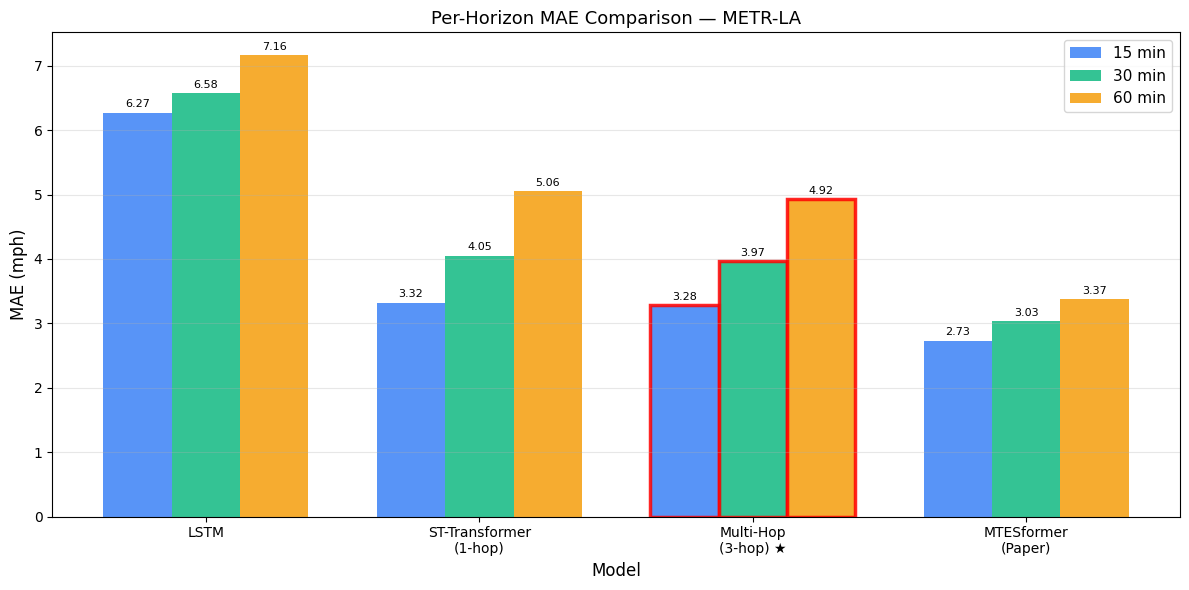

In [31]:
def plot_horizon_comparison():

    models   = ["LSTM", "ST-Transformer\n(1-hop)", "Multi-Hop\n(3-hop) ★", "MTESformer\n(Paper)"]
    mae_15   = [6.27,  3.3208, 3.2803, 2.73]
    mae_30   = [6.58,  4.0521, 3.9709, 3.03]
    mae_60   = [7.16,  5.0573, 4.9250, 3.37]

    x = np.arange(len(models))
    width = 0.25

    fig, ax = plt.subplots(figsize=(12, 6))
    bars1 = ax.bar(x - width, mae_15, width, label='15 min', color='#3B82F6', alpha=0.85)
    bars2 = ax.bar(x,         mae_30, width, label='30 min', color='#10B981', alpha=0.85)
    bars3 = ax.bar(x + width, mae_60, width, label='60 min', color='#F59E0B', alpha=0.85)

    # highlight our model
    for bar in [bars1[2], bars2[2], bars3[2]]:
        bar.set_edgecolor('red')
        bar.set_linewidth(2.5)

    ax.set_xlabel("Model", fontsize=12)
    ax.set_ylabel("MAE (mph)", fontsize=12)
    ax.set_title("Per-Horizon MAE Comparison — METR-LA", fontsize=13)
    ax.set_xticks(x)
    ax.set_xticklabels(models, fontsize=10)
    ax.legend(fontsize=11)
    ax.grid(True, axis='y', alpha=0.3)


    for bars in [bars1, bars2, bars3]:
        for bar in bars:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                    f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=8)

    plt.tight_layout()
    plt.show()

plot_horizon_comparison()

In [66]:
def try_sample(sample_idx, sensor_id=87):

    true_orig, st_orig, mh_orig = predict_sample(sample_idx)

    fig, ax = plt.subplots(figsize=(10, 5))
    time_steps = [f"{(i+1)*5}'" for i in range(12)]

    ax.fill_between(range(12), true_orig[:, sensor_id],
                    alpha=0.1, color='black')
    ax.plot(time_steps, true_orig[:, sensor_id],
            'k-o', linewidth=2.5, markersize=7, label='Ground Truth', zorder=4)
    ax.plot(time_steps, st_orig[:, sensor_id],
            'b--s', linewidth=2, markersize=6, label='ST-Transformer 1-hop', alpha=0.9)
    ax.plot(time_steps, mh_orig[:, sensor_id],
            'r-^', linewidth=2.5, markersize=7, label='Multi-Hop 3-hop', zorder=3)

    mae_st = np.mean(np.abs(st_orig[:, sensor_id] - true_orig[:, sensor_id]))
    mae_mh = np.mean(np.abs(mh_orig[:, sensor_id] - true_orig[:, sensor_id]))
    impr = (mae_st - mae_mh) / mae_st * 100

    ax.set_title(f"Sensor #{sensor_id} — Sample #{sample_idx}\n"
                 f"60-min MAE:  1-hop = {mae_st:.2f} mph   3-hop = {mae_mh:.2f} mph   "
                 f"({'better' if impr>0 else 'worse'} by {abs(impr):.1f}%)",
                 fontsize=12)
    ax.set_xlabel("Prediction Horizon", fontsize=11)
    ax.set_ylabel("Traffic Speed (mph)", fontsize=11)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(bottom=0)
    plt.tight_layout()
    plt.show()


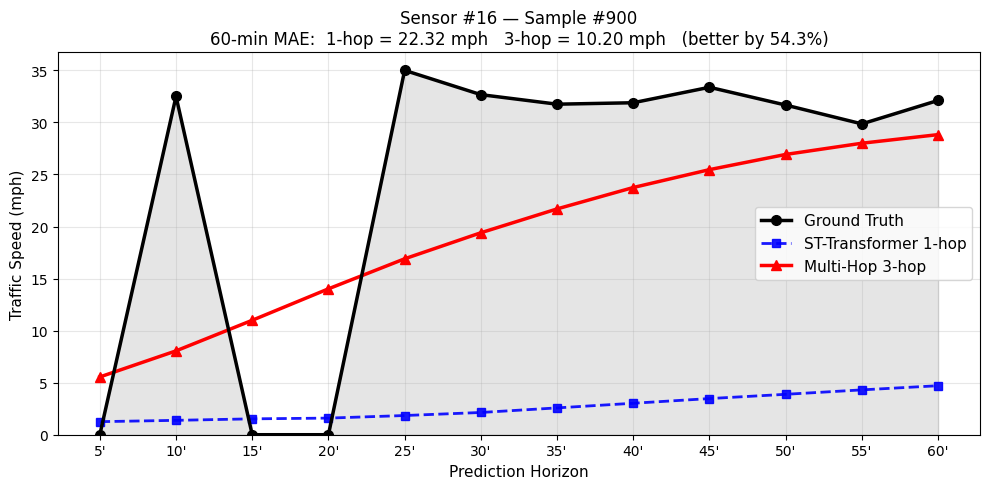

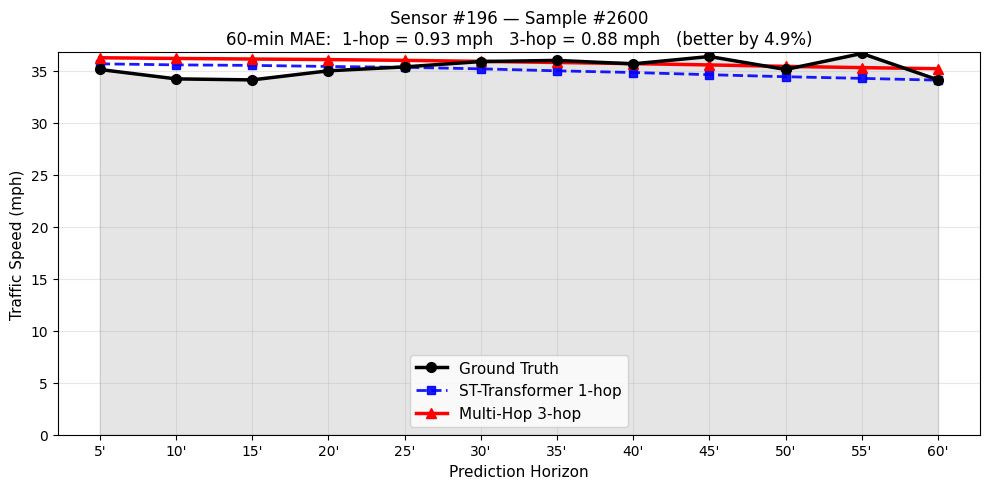

In [63]:
try_sample(sample_idx=900, sensor_id=16) 
try_sample(sample_idx=2600, sensor_id=196) 
# try_sample(sample_idx=4700, sensor_id=127) 

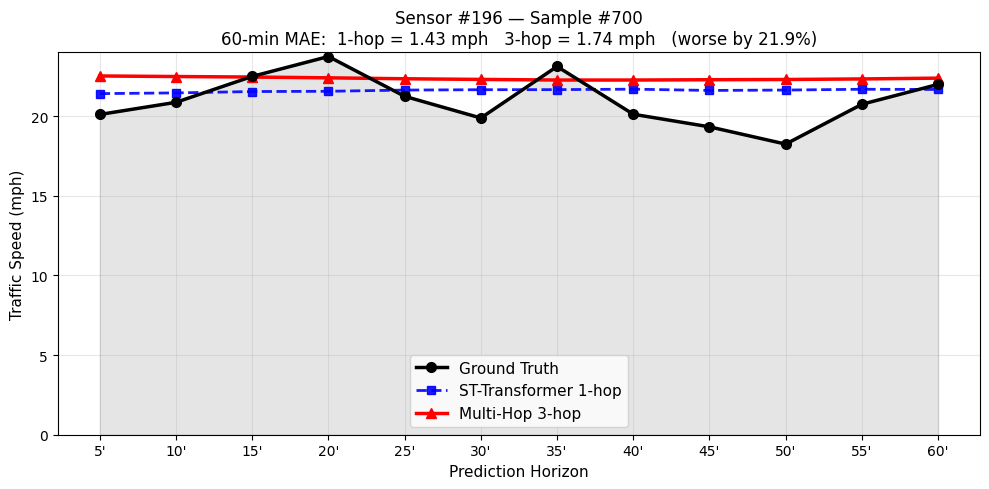

In [65]:
try_sample(sample_idx=700, sensor_id=196) 

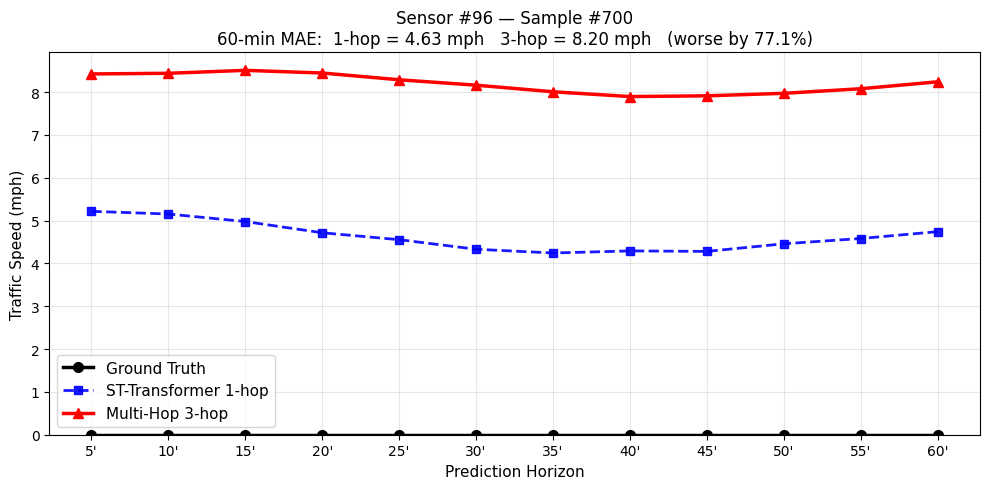

In [67]:
try_sample(sample_idx=700, sensor_id=96) 

In [54]:

interesting = []
for idx in range(0, 6832, 50):
    t, s, m = predict_sample(idx)
    mae_s = np.mean(np.abs(s[:,16] - t[:,16]))
    mae_m = np.mean(np.abs(m[:,16] - t[:,16]))
    impr = (mae_s - mae_m) / mae_s * 100
    speed_range = t[:,16].max() - t[:,16].min()
    if impr > 15 and speed_range > 5: 
        interesting.append((idx, impr, speed_range))

interesting.sort(key=lambda x: x[1], reverse=True)
print("Best samples for demo:")
for idx, impr, rng in interesting[:10]:
    print(f"  sample={idx}  improvement={impr:.1f}%  speed_range={rng:.1f}mph")

Best samples for demo:
  sample=900  improvement=54.3%  speed_range=35.0mph
  sample=2300  improvement=47.6%  speed_range=5.8mph
  sample=5100  improvement=26.4%  speed_range=6.7mph
  sample=4400  improvement=25.7%  speed_range=6.4mph
  sample=2600  improvement=20.0%  speed_range=7.4mph
  sample=2800  improvement=18.3%  speed_range=6.9mph
  sample=3250  improvement=17.6%  speed_range=7.5mph
  sample=4800  improvement=17.3%  speed_range=6.4mph
  sample=2100  improvement=15.3%  speed_range=6.2mph
